# 1. Preparación del Entorno
Primero, importamos las librerías esenciales. Usaremos `pandas` para manipular los datos, `numpy` para operaciones matemáticas, `xgboost` para el modelo y `matplotlib` para visualizar si realmente está aprendiendo.

**Posible problema aquí:** Si lo ejecutas en tu PC local y da error de "module not found", tendrás que instalar las librerías abriendo la terminal y ejecutando: `pip install pandas numpy xgboost scikit-learn matplotlib`.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Configuración visual para las gráficas
plt.style.use('ggplot')

# 2. Creación de un Dataset Sintético Industrial
Para no depender de archivos externos, vamos a generar nuestros propios datos. Simularemos 1000 minutos de operación de una máquina batidora. 

Tenemos variables controlables (Caudal de agua) y variables de contexto (RPM del motor y Temperatura ambiente). El objetivo es predecir la **Temperatura Final de la Masa**, sabiendo que el agua la enfría y las altas RPM la calientan. Añadimos ruido aleatorio para simular la realidad de los sensores.

In [2]:
# Fijamos la semilla aleatoria para que el resultado siempre sea el mismo
np.random.seed(42)

minutos = 1000
tiempo = np.arange(minutos)

# Simulamos las variables de los sensores
rpm_motor = np.random.normal(loc=1500, scale=50, size=minutos)
temp_ambiente = np.sin(tiempo / 50) * 5 + 20 # Sube y baja simulando el día
caudal_agua = np.random.uniform(0, 10, size=minutos) # De 0 a 10 litros/min

# Simulamos la variable objetivo (Temperatura Final de la Masa) con una fórmula física inventada + ruido
ruido_sensor = np.random.normal(0, 0.5, size=minutos)
temp_masa = (rpm_motor * 0.015) + temp_ambiente - (caudal_agua * 1.2) + ruido_sensor

# Juntamos todo en un DataFrame de Pandas
df = pd.DataFrame({
    'minuto': tiempo,
    'rpm_motor': rpm_motor,
    'temp_ambiente': temp_ambiente,
    'caudal_agua': caudal_agua,
    'temp_masa': temp_masa
})

print(df.head())

   minuto    rpm_motor  temp_ambiente  caudal_agua  temp_masa
0       0  1524.835708      20.000000     1.674826  40.708140
1       1  1493.086785      20.099993     1.045678  40.865403
2       2  1532.384427      20.199947     6.364302  35.708137
3       3  1576.151493      20.299820     7.064757  36.134609
4       4  1488.292331      20.399573     0.315861  41.407338


In [3]:
# Fijamos semilla para repetibilidad
np.random.seed(42)
minutos = 1000

# Sensores base
rpm_motor = np.random.normal(loc=1500, scale=50, size=minutos)
temp_ambiente = np.sin(np.arange(minutos) / 50) * 5 + 20
caudal_agua = np.random.uniform(0, 10, size=minutos)

# Inicializamos la temperatura de la masa (empezamos a 20°C)
temp_masa = np.zeros(minutos)
temp_masa[0] = 20.0

# Simulamos la inercia del sistema físico (un bucle temporal real)
for t in range(1, minutes := minutos):
    # 1. El calor generado por el motor depende de las RPM (no lineal)
    calor_motor = (rpm_motor[t] - 1400) ** 2 * 0.00005 
    
    # 2. El efecto de enfriamiento del agua depende de la temperatura ambiente (interacción)
    enfriamiento_agua = caudal_agua[t] * 0.4 * (temp_ambiente[t] / 20.0)
    
    # 3. Termodinámica: La temperatura final depende un 85% de la temperatura que YA tenía la masa,
    # y solo un 15% de los factores externos de este minuto concreto (Inercia térmica real).
    temp_masa[t] = (0.85 * temp_masa[t-1]) + 0.15 * (calor_motor + temp_ambiente[t] - enfriamiento_agua) + np.random.normal(0, 0.1)

# Creamos el DataFrame
df_complejo = pd.DataFrame({
    'rpm_motor': rpm_motor,
    'temp_ambiente': temp_ambiente,
    'caudal_agua': caudal_agua,
    'temp_masa': temp_masa
})

# 3. Ingeniería de Características (El Secreto de las Series Temporales)
XGBoost no lee el tiempo. Si le pasamos la fila del minuto 10, no sabe qué pasó en el minuto 9. Para solucionarlo, creamos **variables de retraso (Lags)**.

**El problema crítico (Los valores nulos):** Al desplazar los datos hacia abajo para crear el pasado, las primeras filas se quedarán vacías (`NaN`). Si le pasas un `NaN` a XGBoost, en este contexto inicial, te dará un error. La solución es usar `.dropna()` para eliminar esos primeros minutos vacíos.

In [4]:
# Creamos la historia pasada
df['temp_masa_hace_1_min'] = df['temp_masa'].shift(1)
df['temp_masa_hace_2_min'] = df['temp_masa'].shift(2)

# Eliminamos las filas con valores nulos generados por el shift
df = df.dropna()

print(df.head())

# Creamos variables retrasadas (Lags)
df_complejo['temp_masa_hace_1_min'] = df_complejo['temp_masa'].shift(1)
df_complejo['temp_masa_hace_2_min'] = df_complejo['temp_masa'].shift(2)
df_complejo['caudal_agua_hace_1_min'] = df_complejo['caudal_agua'].shift(1)

# Eliminamos filas nulas
df_complejo = df_complejo.dropna()

   minuto    rpm_motor  temp_ambiente  caudal_agua  temp_masa  \
2       2  1532.384427      20.199947     6.364302  35.708137   
3       3  1576.151493      20.299820     7.064757  36.134609   
4       4  1488.292331      20.399573     0.315861  41.407338   
5       5  1488.293152      20.499167     9.362122  31.646530   
6       6  1578.960641      20.598561     0.519713  43.579249   

   temp_masa_hace_1_min  temp_masa_hace_2_min  
2             40.865403             40.708140  
3             35.708137             40.865403  
4             36.134609             35.708137  
5             41.407338             36.134609  
6             31.646530             41.407338  


# 4. División de Entrenamiento y Prueba (Train / Test Split)
**El mayor error de novato:** En machine learning tradicional se mezclan los datos aleatoriamente (80% para entrenar, 20% para testar). ¡En series temporales esto es un desastre conocido como *Data Leakage* (Fuga de datos)! Estarías usando datos del futuro para predecir el pasado.

La división debe ser cronológica: usamos los primeros 800 minutos para que el modelo aprenda, y los últimos 198 minutos para ponerlo a prueba en un escenario que jamás ha visto.

In [5]:
# Definimos las variables de entrada (X) y lo que queremos predecir (y)
caracteristicas = ['rpm_motor', 'temp_ambiente', 'caudal_agua', 'temp_masa_hace_1_min', 'temp_masa_hace_2_min']
objetivo = 'temp_masa'

X = df[caracteristicas]
y = df[objetivo]

# Corte secuencial al 80% de los datos
corte = int(len(df) * 0.8)

X_train, X_test = X.iloc[:corte], X.iloc[corte:]
y_train, y_test = y.iloc[:corte], y.iloc[corte:]

print(f"Datos para entrenar: {len(X_train)} minutos")
print(f"Datos para testear: {len(X_test)} minutos")

Datos para entrenar: 798 minutos
Datos para testear: 200 minutos


# 5. Entrenamiento de XGBoost desde cero
Aquí creamos el modelo. Vamos a usar parámetros muy básicos para empezar:
* `n_estimators=100`: Creará 100 árboles de decisión secuenciales.
* `max_depth=3`: Los árboles serán pequeñitos (solo 3 niveles de profundidad).

**Posible problema (Overfitting):** Si pones `max_depth=20`, el modelo memorizará los datos de entrenamiento a la perfección, pero fallará estrepitosamente en los datos de prueba porque será incapaz de generalizar.

In [6]:
# Inicializamos el modelo
modelo = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=3, 
    learning_rate=0.1, 
    random_state=42
)

# ¡Magia! Aquí es donde el modelo aprende de las matemáticas ocultas
modelo.fit(X_train, y_train)

print("¡Modelo entrenado con éxito!")

¡Modelo entrenado con éxito!


# 6. La Prueba de la Verdad: ¿Funciona?
Vamos a pedirle al modelo que prediga las temperaturas de los datos de testeo (los 198 minutos finales que nunca ha visto). Luego, superponemos sus predicciones con la realidad en una gráfica.

El modelo se equivoca en promedio: 0.61 grados


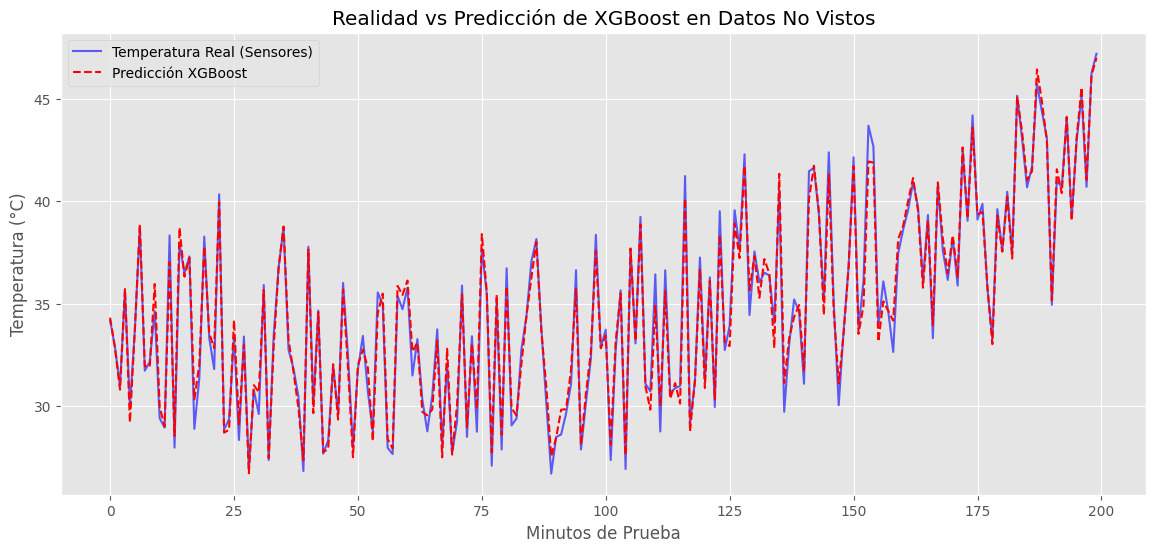

In [7]:
# Hacemos las predicciones
predicciones = modelo.predict(X_test)

# Calculamos el error medio
error = np.sqrt(mean_squared_error(y_test, predicciones))
print(f"El modelo se equivoca en promedio: {error:.2f} grados")

# Visualización
plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Temperatura Real (Sensores)', color='blue', alpha=0.6)
plt.plot(predicciones, label='Predicción XGBoost', color='red', linestyle='dashed')

plt.title('Realidad vs Predicción de XGBoost en Datos No Vistos')
plt.xlabel('Minutos de Prueba')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.show()

# 7. Entendiendo por qué toma decisiones (Explicabilidad)
Una de las grandes ventajas de XGBoost es que no es una caja negra impenetrable. Podemos pedirle que nos diga qué sensores han sido los más importantes matemáticamente para predecir la temperatura.

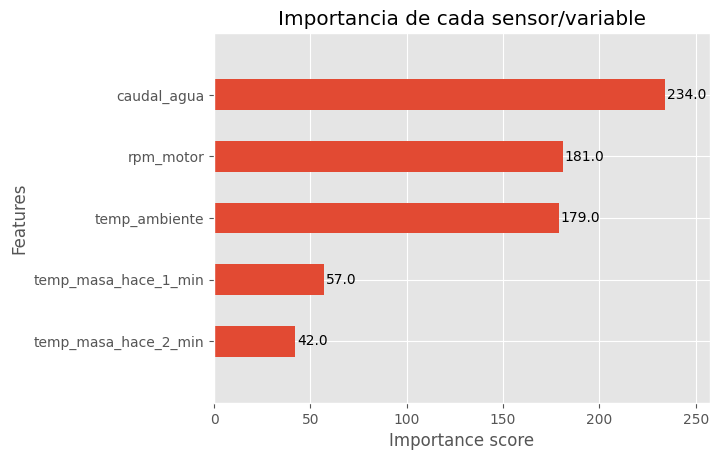

In [8]:
# Graficamos la importancia de las características
xgb.plot_importance(modelo, height=0.5, importance_type='weight')
plt.title('Importancia de cada sensor/variable')
plt.show()

Error medio en el dataset complejo: 0.4381 grados


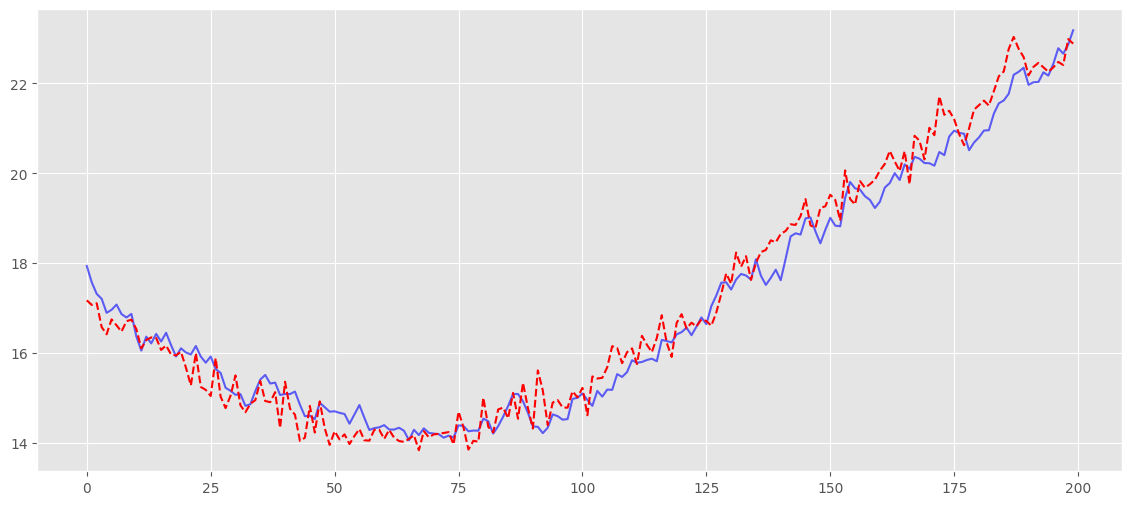

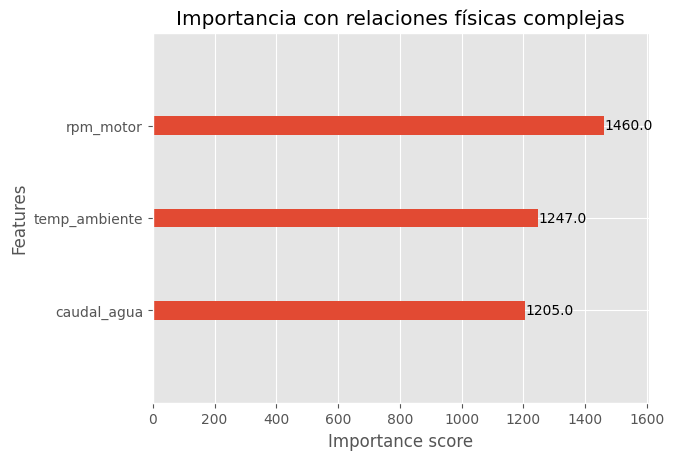

In [9]:
# Eliminamos filas nulas
df_complejo = df_complejo.dropna()

# Definimos características y objetivo
caracteristicas_complejas = ['rpm_motor', 'temp_ambiente', 'caudal_agua']
objetivo_complejo = 'temp_masa'

X_comp = df_complejo[caracteristicas_complejas]
y_comp = df_complejo[objetivo_complejo]

# División cronológica (80/20)
corte_comp = int(len(df_complejo) * 0.8)
X_train_c, X_test_c = X_comp.iloc[:corte_comp], X_comp.iloc[corte_comp:]
y_train_c, y_test_c = y_comp.iloc[:corte_comp], y_comp.iloc[corte_comp:]

# Modelo XGBoost
modelo_complejo = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
modelo_complejo.fit(X_train_c, y_train_c)

# Predicción e Importancia
pred_c = modelo_complejo.predict(X_test_c)
error_c = np.sqrt(mean_squared_error(y_test_c, pred_c))
print(f"Error medio en el dataset complejo: {error_c:.4f} grados")

# Visualización
plt.figure(figsize=(14, 6))
plt.plot(y_test_c.values, label='Temperatura Real (Sensores)', color='blue', alpha=0.6)
plt.plot(pred_c, label='Predicción XGBoost', color='red', linestyle='dashed')

# Gráfica de importancia
xgb.plot_importance(modelo_complejo, importance_type='weight')
plt.title("Importancia con relaciones físicas complejas")
plt.show()

Error medio en el dataset complejo: 0.1492 grados


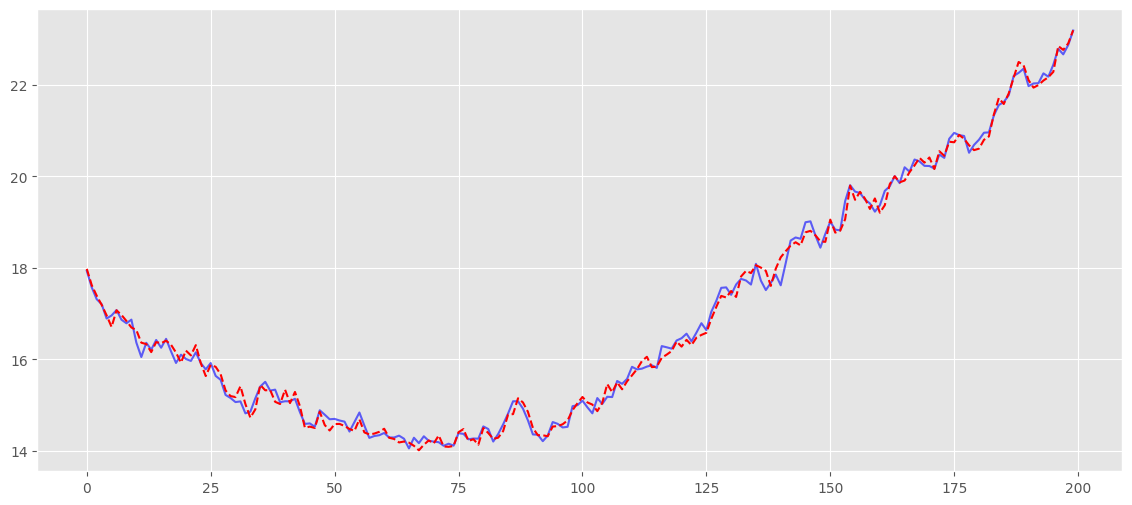

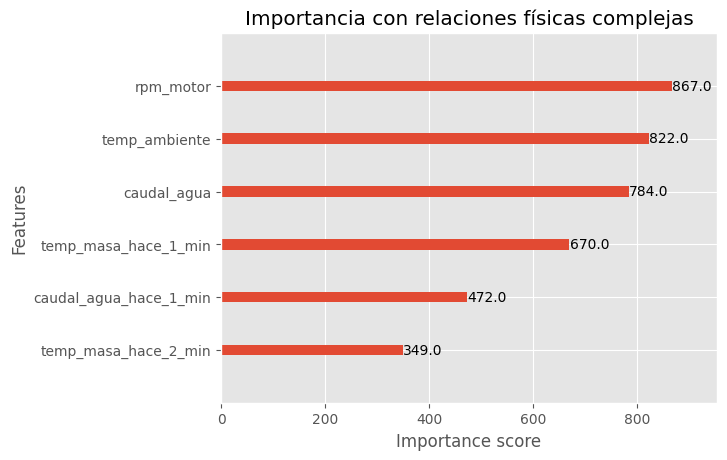

In [10]:
# Creamos variables retrasadas (Lags)
df_complejo['temp_masa_hace_1_min'] = df_complejo['temp_masa'].shift(1)
df_complejo['temp_masa_hace_2_min'] = df_complejo['temp_masa'].shift(2)
df_complejo['caudal_agua_hace_1_min'] = df_complejo['caudal_agua'].shift(1)

# Eliminamos filas nulas
df_complejo = df_complejo.dropna()

# Definimos características y objetivo
caracteristicas_complejas = ['rpm_motor', 'temp_ambiente', 'caudal_agua', 'temp_masa_hace_1_min', 'temp_masa_hace_2_min', 'caudal_agua_hace_1_min']
objetivo_complejo = 'temp_masa'

X_comp = df_complejo[caracteristicas_complejas]
y_comp = df_complejo[objetivo_complejo]

# División cronológica (80/20)
corte_comp = int(len(df_complejo) * 0.8)
X_train_c, X_test_c = X_comp.iloc[:corte_comp], X_comp.iloc[corte_comp:]
y_train_c, y_test_c = y_comp.iloc[:corte_comp], y_comp.iloc[corte_comp:]

# Modelo XGBoost
modelo_complejo = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
modelo_complejo.fit(X_train_c, y_train_c)

# Predicción e Importancia
pred_c = modelo_complejo.predict(X_test_c)
error_c = np.sqrt(mean_squared_error(y_test_c, pred_c))
print(f"Error medio en el dataset complejo: {error_c:.4f} grados")

# Visualización
plt.figure(figsize=(14, 6))
plt.plot(y_test_c.values, label='Temperatura Real (Sensores)', color='blue', alpha=0.6)
plt.plot(pred_c, label='Predicción XGBoost', color='red', linestyle='dashed')

# Gráfica de importancia
xgb.plot_importance(modelo_complejo, importance_type='weight')
plt.title("Importancia con relaciones físicas complejas")
plt.show()

Error medio en el dataset complejo: 0.3175 grados


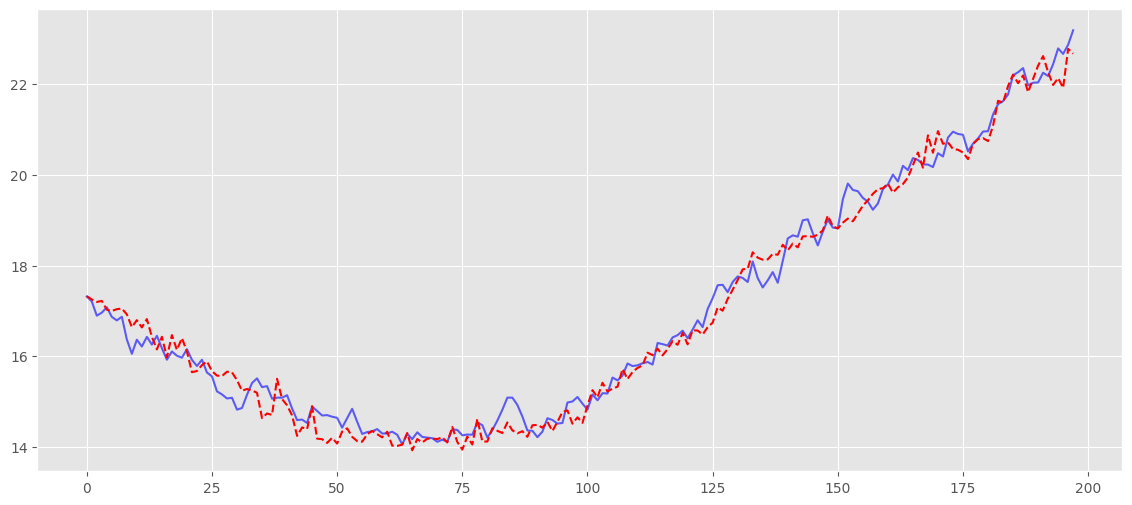

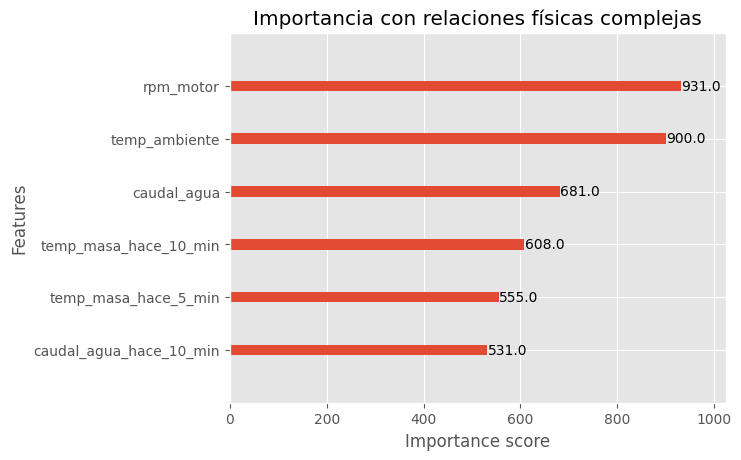

In [11]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Fijamos semilla para repetibilidad
np.random.seed(42)
minutos = 1000

# Sensores base
rpm_motor = np.random.normal(loc=1500, scale=50, size=minutos)
temp_ambiente = np.sin(np.arange(minutos) / 50) * 5 + 20
caudal_agua = np.random.uniform(0, 10, size=minutos)

# Inicializamos la temperatura de la masa (empezamos a 20°C)
temp_masa = np.zeros(minutos)
temp_masa[0] = 20.0

# Simulamos la inercia del sistema físico (un bucle temporal real)
for t in range(1, minutes := minutos):
    # 1. El calor generado por el motor depende de las RPM (no lineal)
    calor_motor = (rpm_motor[t] - 1400) ** 2 * 0.00005 
    
    # 2. El efecto de enfriamiento del agua depende de la temperatura ambiente (interacción)
    enfriamiento_agua = caudal_agua[t] * 0.4 * (temp_ambiente[t] / 20.0)
    
    # 3. Termodinámica: La temperatura final depende un 85% de la temperatura que YA tenía la masa,
    # y solo un 15% de los factores externos de este minuto concreto (Inercia térmica real).
    temp_masa[t] = (0.85 * temp_masa[t-1]) + 0.15 * (calor_motor + temp_ambiente[t] - enfriamiento_agua) + np.random.normal(0, 0.1)

# Creamos el DataFrame
df_complejo = pd.DataFrame({
    'rpm_motor': rpm_motor,
    'temp_ambiente': temp_ambiente,
    'caudal_agua': caudal_agua,
    'temp_masa': temp_masa
})
# Creamos variables retrasadas (Lags)
df_complejo['temp_masa_hace_10_min'] = df_complejo['temp_masa'].shift(10)
df_complejo['temp_masa_hace_5_min'] = df_complejo['temp_masa'].shift(5)
df_complejo['caudal_agua_hace_10_min'] = df_complejo['caudal_agua'].shift(10)

# Eliminamos filas nulas
df_complejo = df_complejo.dropna()

# Definimos características y objetivo
caracteristicas_complejas = ['rpm_motor', 'temp_ambiente', 'caudal_agua', 'temp_masa_hace_10_min', 'temp_masa_hace_5_min', 'caudal_agua_hace_10_min']
objetivo_complejo = 'temp_masa'

X_comp = df_complejo[caracteristicas_complejas]
y_comp = df_complejo[objetivo_complejo]

# División cronológica (80/20)
corte_comp = int(len(df_complejo) * 0.8)
X_train_c, X_test_c = X_comp.iloc[:corte_comp], X_comp.iloc[corte_comp:]
y_train_c, y_test_c = y_comp.iloc[:corte_comp], y_comp.iloc[corte_comp:]

# Modelo XGBoost
modelo_complejo = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
modelo_complejo.fit(X_train_c, y_train_c)

# Predicción e Importancia
pred_c = modelo_complejo.predict(X_test_c)
error_c = np.sqrt(mean_squared_error(y_test_c, pred_c))
print(f"Error medio en el dataset complejo: {error_c:.4f} grados")

# Visualización
plt.figure(figsize=(14, 6))
plt.plot(y_test_c.values, label='Temperatura Real (Sensores)', color='blue', alpha=0.6)
plt.plot(pred_c, label='Predicción XGBoost', color='red', linestyle='dashed')

# Gráfica de importancia
xgb.plot_importance(modelo_complejo, importance_type='weight')
plt.title("Importancia con relaciones físicas complejas")
plt.show()

Error medio en el dataset complejo: 0.3397 grados


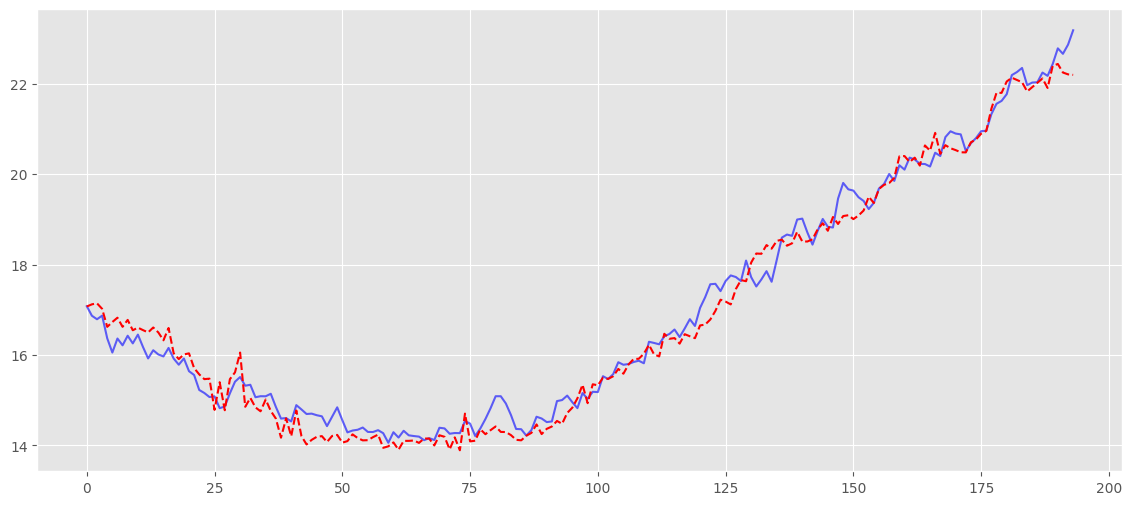

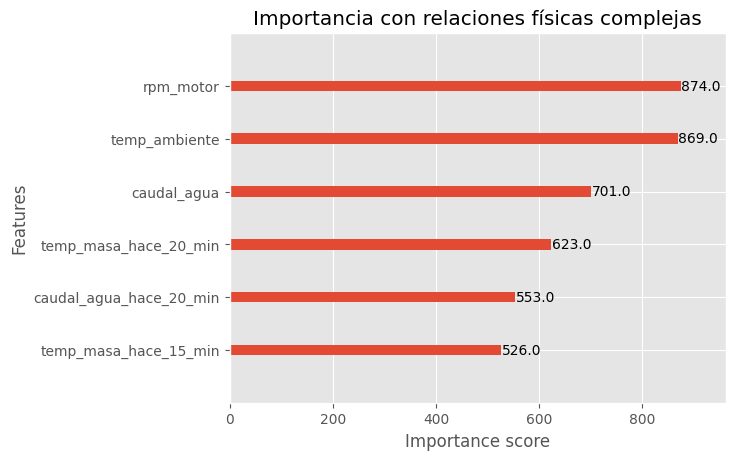

In [12]:
# Creamos variables retrasadas (Lags)
df_complejo['temp_masa_hace_20_min'] = df_complejo['temp_masa'].shift(20)
df_complejo['temp_masa_hace_15_min'] = df_complejo['temp_masa'].shift(15)
df_complejo['caudal_agua_hace_20_min'] = df_complejo['caudal_agua'].shift(20)

# Eliminamos filas nulas
df_complejo = df_complejo.dropna()

# Definimos características y objetivo
caracteristicas_complejas = ['rpm_motor', 'temp_ambiente', 'caudal_agua', 'temp_masa_hace_20_min', 'temp_masa_hace_15_min', 'caudal_agua_hace_20_min']
objetivo_complejo = 'temp_masa'

X_comp = df_complejo[caracteristicas_complejas]
y_comp = df_complejo[objetivo_complejo]

# División cronológica (80/20)
corte_comp = int(len(df_complejo) * 0.8)
X_train_c, X_test_c = X_comp.iloc[:corte_comp], X_comp.iloc[corte_comp:]
y_train_c, y_test_c = y_comp.iloc[:corte_comp], y_comp.iloc[corte_comp:]

# Modelo XGBoost
modelo_complejo = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
modelo_complejo.fit(X_train_c, y_train_c)

# Predicción e Importancia
pred_c = modelo_complejo.predict(X_test_c)
error_c = np.sqrt(mean_squared_error(y_test_c, pred_c))
print(f"Error medio en el dataset complejo: {error_c:.4f} grados")

# Visualización
plt.figure(figsize=(14, 6))
plt.plot(y_test_c.values, label='Temperatura Real (Sensores)', color='blue', alpha=0.6)
plt.plot(pred_c, label='Predicción XGBoost', color='red', linestyle='dashed')

# Gráfica de importancia
xgb.plot_importance(modelo_complejo, importance_type='weight')
plt.title("Importancia con relaciones físicas complejas")
plt.show()

Test with GRIDSEARCH

In [13]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import itertools

# Configuración visual para las gráficas
plt.style.use('ggplot')

In [14]:
# Cargar el dataset real
df = pd.read_csv('water_flow.csv', sep=';', decimal=',')

# Asegurarse de que el timestamp sea tipo fecha y ordenar cronológicamente
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# Convertir columnas a numéricas por seguridad (y eliminar nulos)
columnas_numericas = ['flow_orifice_plate', 'flow_coriolis', 'closing_disturbance_valve_ptr', 'pump_RPM']
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

print("Datos cargados correctamente. Dimensiones:", df.shape)
print(df.head())

Datos cargados correctamente. Dimensiones: (769, 5)
            timestamp  flow_orifice_plate  flow_coriolis  \
0 2024-11-16 12:03:07                 0.0      -0.005482   
1 2024-11-16 12:03:08                 0.0      -0.007228   
2 2024-11-16 12:03:09                 0.0      -0.013782   
3 2024-11-16 12:03:10                 0.0       0.000442   
4 2024-11-16 12:03:11                 0.0      -0.003881   

   closing_disturbance_valve_ptr  pump_RPM  
0                              0       0.0  
1                              0       0.0  
2                              0       0.0  
3                              0       0.0  
4                              0       0.0  


In [ ]:
def evaluar_modelo_xgboost(df, features_base, objetivo, lags=1, n_estimators=100, max_depth=3, learning_rate=0.1):
    """
    Genera características de retraso (lags) dinámicamente, entrena el modelo y devuelve el error y las predicciones.
    """
    df_temp = df.copy()
    caracteristicas_finales = list(features_base)
    
    # 1. Ingeniería de características: Crear Lags
    for feature in features_base:
        for lag in range(1, lags + 1):
            nombre_col = f"{feature}_lag_{lag}"
            df_temp[nombre_col] = df_temp[feature].shift(lag)
            caracteristicas_finales.append(nombre_col)
            
    # Eliminar las filas con nulos generados por los desplazamientos
    df_temp = df_temp.dropna()
    # 2. Definir matriz de características (X) y objetivo (y)
    X = df_temp[caracteristicas_finales]
    y = df_temp[objetivo]
    
    # 3. División cronológica (80% Entrenamiento / 20% Prueba)
    corte = int(len(df_temp) * 0.7)
    X_train, X_test = X.iloc[:corte], X.iloc[corte:]
    y_train, y_test = y.iloc[:corte], y.iloc[corte:]
    
    # 4. Entrenar XGBoost
    modelo = xgb.XGBRegressor(
        n_estimators=n_estimators, 
        max_depth=max_depth, 
        learning_rate=learning_rate, 
        random_state=42,
        n_jobs=-1 # Usar todos los hilos del procesador
    )
    modelo.fit(X_train, y_train)
    
    # 5. Predecir y calcular error
    predicciones = modelo.predict(X_test)
    error = np.sqrt(mean_squared_error(y_test, predicciones))
    
    return error, modelo, X_test, y_test, predicciones

In [16]:
# Definir variables. Quieres predecir 'pump_RPM' usando la válvula y el caudal
variables_entrada = ['closing_disturbance_valve_ptr', 'flow_coriolis'] 
variable_objetivo = 'pump_RPM'

# Definir las combinaciones de hiperparámetros que queremos probar
opciones_lags = [10]
opciones_n_estimators = [50, 100, 200]
opciones_max_depth = [2, 3, 5]

resultados = []

print("Iniciando pruebas de combinaciones...")
# Probar todas las combinaciones posibles
for lag, n_est, depth in itertools.product(opciones_lags, opciones_n_estimators, opciones_max_depth):
    
    error, _, _, _, _ = evaluar_modelo_xgboost(
        df=df, 
        features_base=variables_entrada, 
        objetivo=variable_objetivo, 
        lags=lag, 
        n_estimators=n_est, 
        max_depth=depth
    )
    resultados.append({
        'Lags': lag,
        'N_Estimators': n_est,
        'Max_Depth': depth,
        'RMSE': error
    })

# Convertir a DataFrame para ver los resultados ordenados de mejor a peor
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('RMSE').reset_index(drop=True)

print("\n=== Mejores combinaciones de parámetros ===")
print(df_resultados.head(10))

Iniciando pruebas de combinaciones...
Variables de entrada: ['closing_disturbance_valve_ptr', 'flow_coriolis', 'closing_disturbance_valve_ptr_lag_1', 'closing_disturbance_valve_ptr_lag_2', 'closing_disturbance_valve_ptr_lag_3', 'closing_disturbance_valve_ptr_lag_4', 'closing_disturbance_valve_ptr_lag_5', 'closing_disturbance_valve_ptr_lag_6', 'closing_disturbance_valve_ptr_lag_7', 'closing_disturbance_valve_ptr_lag_8', 'closing_disturbance_valve_ptr_lag_9', 'closing_disturbance_valve_ptr_lag_10', 'flow_coriolis_lag_1', 'flow_coriolis_lag_2', 'flow_coriolis_lag_3', 'flow_coriolis_lag_4', 'flow_coriolis_lag_5', 'flow_coriolis_lag_6', 'flow_coriolis_lag_7', 'flow_coriolis_lag_8', 'flow_coriolis_lag_9', 'flow_coriolis_lag_10']
Variables de entrada: ['closing_disturbance_valve_ptr', 'flow_coriolis', 'closing_disturbance_valve_ptr_lag_1', 'closing_disturbance_valve_ptr_lag_2', 'closing_disturbance_valve_ptr_lag_3', 'closing_disturbance_valve_ptr_lag_4', 'closing_disturbance_valve_ptr_lag_5',

Entrenando el mejor modelo (Lags: 10, Árboles: 100, Profundidad: 3)
Variables de entrada: ['closing_disturbance_valve_ptr', 'flow_coriolis', 'closing_disturbance_valve_ptr_lag_1', 'closing_disturbance_valve_ptr_lag_2', 'closing_disturbance_valve_ptr_lag_3', 'closing_disturbance_valve_ptr_lag_4', 'closing_disturbance_valve_ptr_lag_5', 'closing_disturbance_valve_ptr_lag_6', 'closing_disturbance_valve_ptr_lag_7', 'closing_disturbance_valve_ptr_lag_8', 'closing_disturbance_valve_ptr_lag_9', 'closing_disturbance_valve_ptr_lag_10', 'flow_coriolis_lag_1', 'flow_coriolis_lag_2', 'flow_coriolis_lag_3', 'flow_coriolis_lag_4', 'flow_coriolis_lag_5', 'flow_coriolis_lag_6', 'flow_coriolis_lag_7', 'flow_coriolis_lag_8', 'flow_coriolis_lag_9', 'flow_coriolis_lag_10']


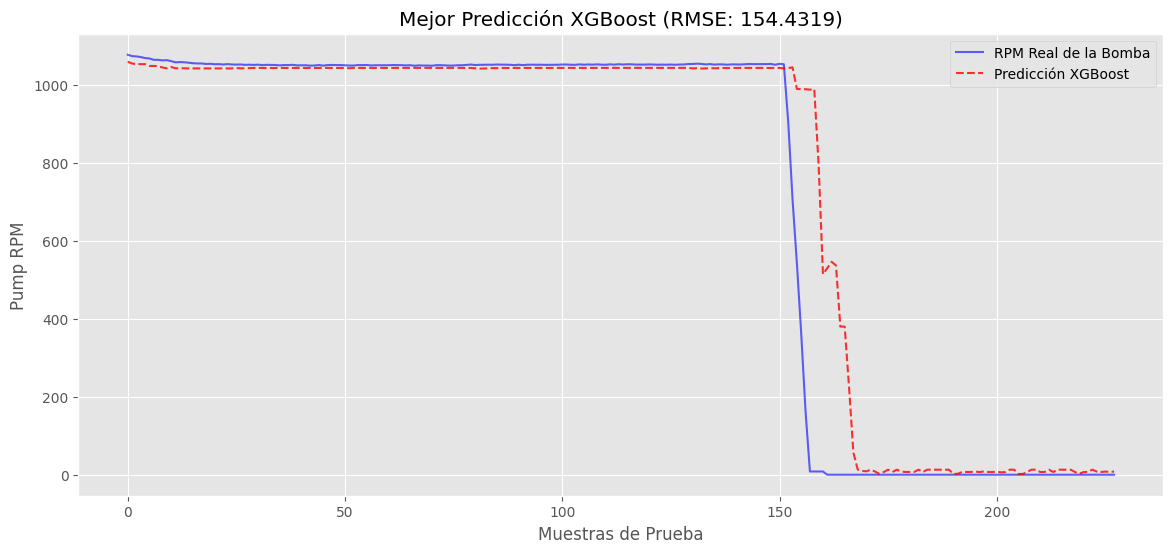

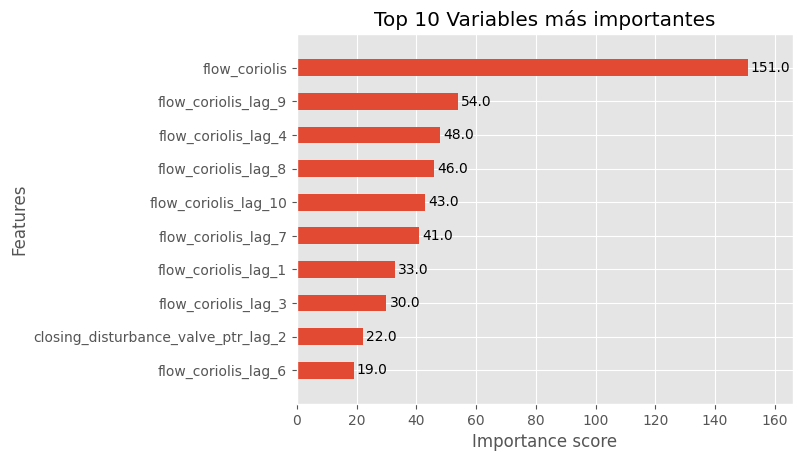

In [17]:
# Tomar los parámetros del mejor modelo de la tabla anterior
mejor_config = df_resultados.iloc[0]

print(f"Entrenando el mejor modelo (Lags: {int(mejor_config['Lags'])}, "
      f"Árboles: {int(mejor_config['N_Estimators'])}, "
      f"Profundidad: {int(mejor_config['Max_Depth'])})")

error_final, mejor_modelo, X_test_final, y_test_final, preds_final = evaluar_modelo_xgboost(
    df=df, 
    features_base=variables_entrada, 
    objetivo=variable_objetivo, 
    lags=int(mejor_config['Lags']), 
    n_estimators=int(mejor_config['N_Estimators']), 
    max_depth=int(mejor_config['Max_Depth'])
)

# Gráfica: Realidad vs Predicción
plt.figure(figsize=(14, 6))
plt.plot(y_test_final.values, label='RPM Real de la Bomba', color='blue', alpha=0.6)
plt.plot(preds_final, label='Predicción XGBoost', color='red', linestyle='dashed', alpha=0.8)
plt.title(f'Mejor Predicción XGBoost (RMSE: {error_final:.4f})')
plt.xlabel('Muestras de Prueba')
plt.ylabel('Pump RPM')
plt.legend()
plt.show()

# Gráfica: Importancia de las variables
xgb.plot_importance(mejor_modelo, height=0.5, importance_type='weight', max_num_features=10)
plt.title('Top 10 Variables más importantes')
plt.show()